   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
Confusion Matrix:
 [[13  0  0]
 [ 0 16  0]
 [ 0  0  9]]
Binary Confusion Matrix:
 [[25  0]
 [ 0 13]]
TP: 13
TN: 25
FP: 0
FN: 0
Accuracy: 1.0
Error Rate: 0.0
Precision: 1.0
Recall: 1.0


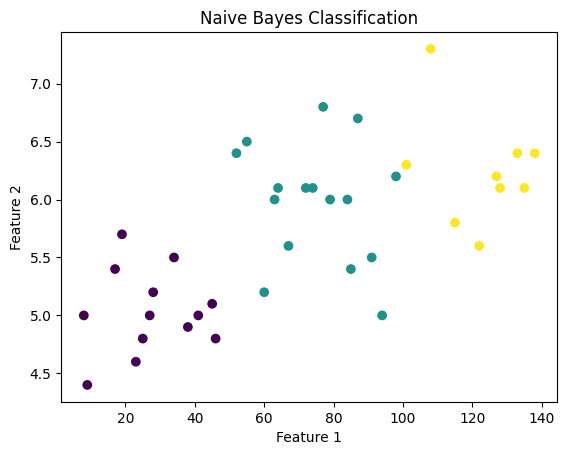

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

data = pd.read_csv('iris.csv')
print(data.head())

X = data.iloc[:, :-1]   # all columns except last
Y = data.iloc[:, -1]   # last column (species)

le = LabelEncoder()
Y = le.fit_transform(Y)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=0)

model = GaussianNB()
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

cm = confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix:\n", cm)

Y_test_bin = (Y_test == 0).astype(int)
Y_pred_bin = (Y_pred == 0).astype(int)

cm_bin = confusion_matrix(Y_test_bin, Y_pred_bin)
print("Binary Confusion Matrix:\n", cm_bin)

TN = cm_bin[0][0]
FP = cm_bin[0][1]
FN = cm_bin[1][0]
TP = cm_bin[1][1]

print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

accuracy = (TP + TN) / (TP + TN + FP + FN)
print("Accuracy:", accuracy)

error_rate = (FP + FN) / (TP + TN + FP + FN)
print("Error Rate:", error_rate)

precision = TP / (TP + FP)
print("Precision:", precision)

recall = TP / (TP + FN)
print("Recall:", recall)

plt.scatter(X_test.iloc[:,0], X_test.iloc[:,1], c=Y_pred)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Naive Bayes Classification")
plt.show()